# Laser Off Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

# Set Instruments Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)
params.MSO5_set_standard_counts(MS)
p_att.write(f'VOLT {params.device_line_1['v_attenuator_vals']['att_blue_v']}')
# yoko.current(0)
# Check shielding: box and fridge entry 

# Import

In [1]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
from ipywidgets import interact, IntSlider
initialise_or_create_database_at("./2026-05-11_SNSPD11.db")
import snspd
params = snspd.snspd('snspd11.yaml')

# Set up experiment
exp_name = 'SNSPD11_11_05_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260611-26308-qcodes.log
Experiment loaded. Last ID no: 299


In [2]:
import importlib
importlib.reload(snspd)
params = snspd.snspd('snspd11.yaml')

# Instruments

In [4]:
params.device_line_2['name']

'R7C6'

In [8]:
np.arange(0,-13.25e-6, -0.25e-6)

array([ 0.000e+00, -2.500e-07, -5.000e-07, -7.500e-07, -1.000e-06,
       -1.250e-06, -1.500e-06, -1.750e-06, -2.000e-06, -2.250e-06,
       -2.500e-06, -2.750e-06, -3.000e-06, -3.250e-06, -3.500e-06,
       -3.750e-06, -4.000e-06, -4.250e-06, -4.500e-06, -4.750e-06,
       -5.000e-06, -5.250e-06, -5.500e-06, -5.750e-06, -6.000e-06,
       -6.250e-06, -6.500e-06, -6.750e-06, -7.000e-06, -7.250e-06,
       -7.500e-06, -7.750e-06, -8.000e-06, -8.250e-06, -8.500e-06,
       -8.750e-06, -9.000e-06, -9.250e-06, -9.500e-06, -9.750e-06,
       -1.000e-05, -1.025e-05, -1.050e-05, -1.075e-05, -1.100e-05,
       -1.125e-05, -1.150e-05, -1.175e-05, -1.200e-05, -1.225e-05,
       -1.250e-05, -1.275e-05, -1.300e-05])

In [15]:
params.device_line_2['IDs']['critical_current']

242

Text(0.5, 1.0, 'Critical current\nID 242 2026-05-19 12:46:47\nR7C6')

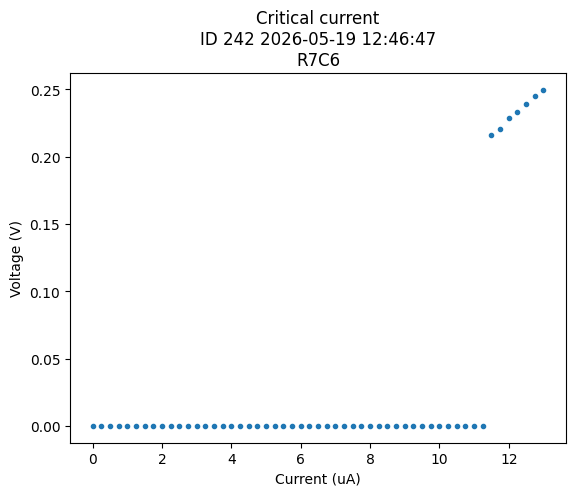

In [22]:
ID = params.device_line_2['IDs']['critical_current']
data = load_by_id(ID).get_parameter_data()
current = data['dmm_volt']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
plt.plot(-current*1e6, -voltage, '.')
plt.xlabel('Current (uA)')
plt.ylabel('Voltage (V)')
plt.title(params.make_title(ID=ID, title='Critical current', extra=params.device_line_2['name']))

([<Axes: title={'center': 'Run #243, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

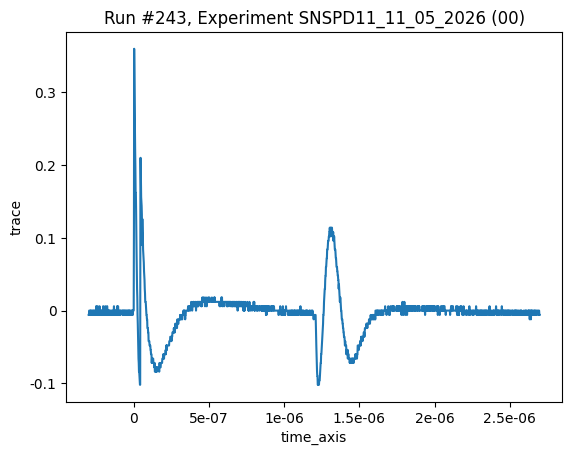

In [25]:
plot_by_id(243)

In [38]:
params.device_line_2['IDs']['light_counts']['run_5v']

246

In [60]:
CR1

array([0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
       0.00000e+00, 0.00000e+00, 1.00000e+00, 1.00000e+00, 0.00000e+00,
       8.00000e+00, 3.00000e+00, 7.00000e+00, 8.00000e+00, 7.00000e+00,
       4.00000e+00, 1.30000e+01, 1.50000e+01, 1.50000e+01, 1.10000e+01,
       1.30000e+01, 1.60000e+01, 1.50000e+01, 1.30000e+01, 1.20000e+01,
       2.70000e+01, 6.00000e+01, 1.30000e+02, 4.16000e+02, 1.00300e+03,
       2.20500e+03, 4.29600e+03, 7.82700e+03, 1.40440e+04, 2.35600e+04,
       4.43520e+04, 7.29700e+04, 1.12444e+05, 1.53820e+05, 2.01528e+05,
       0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00,
       1.00000e+00, 5.00000e+00, 1.90000e+02, 6.00000e+00, 6.00000e+00,
       8.30000e+01, 2.80000e+01, 3.40000e+02])

Check match:201528.0 (test) = [201528.]?


array([-9.75e-06])

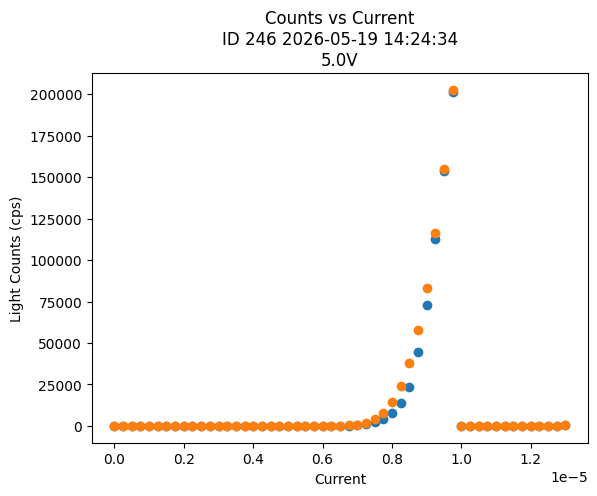

In [3]:
ID = params.device_line_2['IDs']['light_counts']['run_5v']
data = load_by_id(ID).get_parameter_data()
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
current = data['CR1']['yoko_current']
v_attenuator = data['v_attenuator']['v_attenuator']
plt.plot(-current, CR1, 'o', label='Threshold 1 (HIGH)')
plt.plot(-current, CR2, 'o', label='Threshold 2 (LOW)')
plt.title(params.make_title(ID=ID, title='Counts vs Current', extra = f'{v_attenuator[0]}V'))
plt.xlabel('Current')
plt.ylabel('Light Counts (cps)')

idx, _ = params.match(max(CR1), CR1, tol=5)
current[idx]

In [4]:
data = load_by_id(ID).get_parameter_data()
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
current = data['CR1']['yoko_current']

In [5]:
data.keys()

dict_keys(['CR1', 'CR2', 'counts1', 'counts2', 'dmm_volt', 'interval', 'meas_time', 'n_captures', 'power90', 'threshold1', 'threshold2', 'total_counts1', 'total_counts2', 'trace_time', 'v_attenuator', 'v_scale', 'wavelength'])

In [8]:
data['threshold2']['threshold2'] # threshold 2 was saving the value for threshold 1 at this point due to bug 

array([0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024,
       0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024,
       0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024,
       0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024,
       0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024,
       0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan,   nan,

In [7]:
data['threshold1']['threshold1']

array([0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024,
       0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024,
       0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024,
       0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024,
       0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024,
       0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024, 0.024,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan,   nan,

In [46]:
ID = params.device_line_2['IDs']['light_counts']['run_5v']
data = load_by_id(ID).get_parameter_data()

Text(0, 0.5, 'Light Counts (cps)')

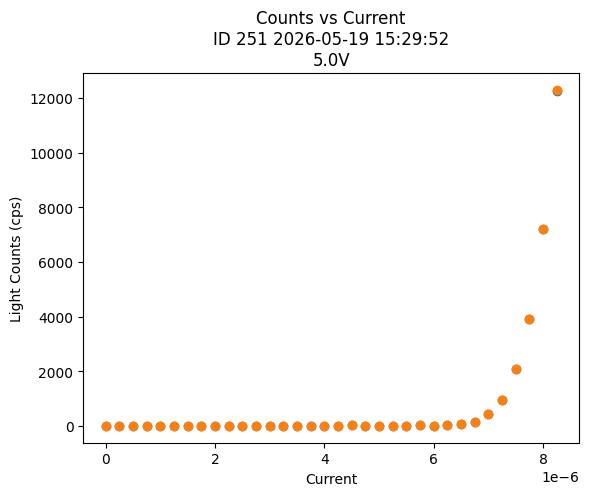

In [68]:
ID = 251
data = load_by_id(ID).get_parameter_data()
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
current = data['CR1']['yoko_current']
v_attenuator = data['v_attenuator']['v_attenuator']
plt.plot(-current, CR1, 'o', label='Threshold 1 (HIGH)')
plt.plot(-current, CR2, 'o', label='Threshold 2 (LOW)')
plt.title(params.make_title(ID=ID, title='Counts vs Current', extra = f'{v_attenuator[0]}V'))
plt.xlabel('Current')
plt.ylabel('Light Counts (cps)')

Check match:79619.0 (test) = [79619.]?


array([-9.5e-06])

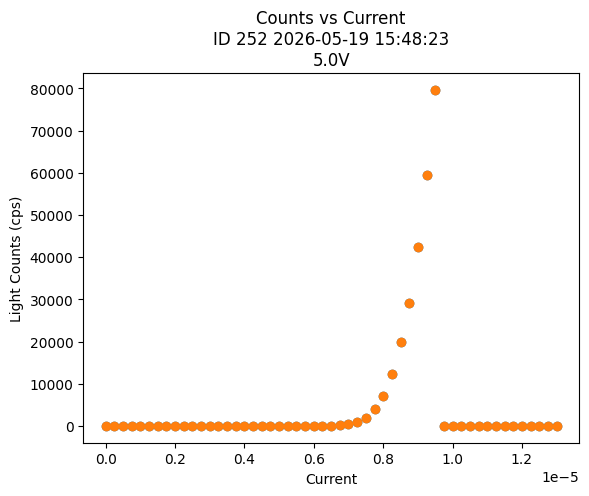

In [93]:
ID = 252
data = load_by_id(ID).get_parameter_data()
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
current = data['CR1']['yoko_current']
v_attenuator = data['v_attenuator']['v_attenuator']
plt.plot(-current, CR1, 'o', label='Threshold 1 (HIGH)')
plt.plot(-current, CR2, 'o', label='Threshold 2 (LOW)')
plt.title(params.make_title(ID=ID, title='Counts vs Current', extra = f'{v_attenuator[0]}V'))
plt.xlabel('Current')
plt.ylabel('Light Counts (cps)')

idx, _ = params.match(max(CR1), CR1, tol=5)
current[idx]

# Dark Counts

16


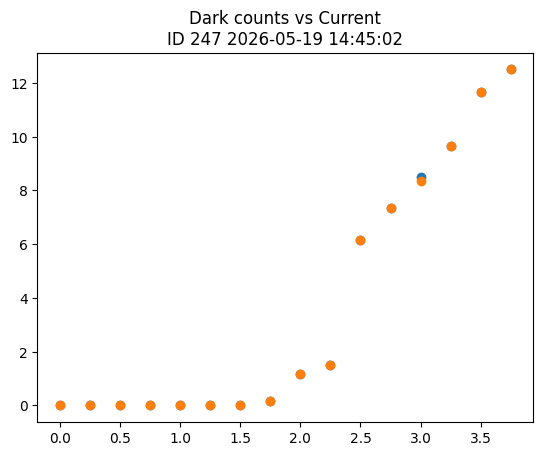

In [114]:
IDdcr = params.device_line_2['IDs']['dark_counts']['run1']
ID = IDdcr
data = load_by_id(ID).get_parameter_data()
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
current = data['CR1']['yoko_current']
plt.plot(-current*1e6, CR1, 'o', label='Threshold 1 (HIGH)')
plt.plot(-current*1e6, CR2, 'o', label='Threshold 2 (LOW)')
plt.title(params.make_title(ID=ID, title='Dark counts vs Current'))
print(len(current))

53


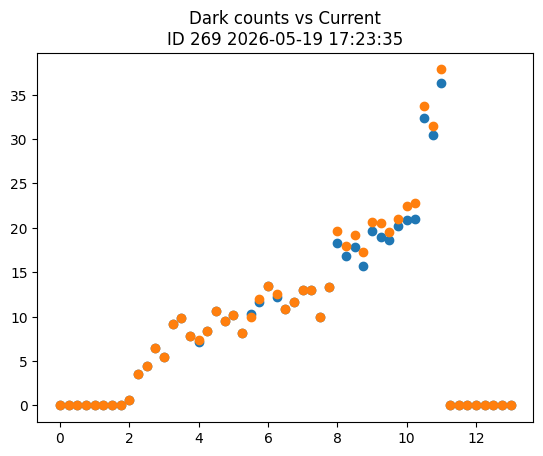

In [113]:
IDdcr = params.device_line_2['IDs']['dark_counts']['run2']
ID = IDdcr
data = load_by_id(ID).get_parameter_data()
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
current = data['CR1']['yoko_current']
plt.plot(-current*1e6, CR1, 'o', label='Threshold 1 (HIGH)')
plt.plot(-current*1e6, CR2, 'o', label='Threshold 2 (LOW)')
plt.title(params.make_title(ID=ID, title='Dark counts vs Current'))
print(len(current))

Skeptical about how much lower the ID 252 result is than ID 246

In [78]:
Nphotons = load_by_id(params.NphotonsID['vs_dB']).get_parameter_data()['Nphotons']['Nphotons']
v_att_range = params.att_blue_v_attenuator_range
v_att = np.arange(v_att_range['start'], v_att_range['stop'], v_att_range['step'])
len(v_att), len(Nphotons)
v_att[-11] # Choose 5V
Nphotons_5v = Nphotons[-11]
Nphotons_5v

np.float64(360471.557889234)

Sanity check: Nphotons corresponding to 1550nm at 5V is the same for both lists 

In [85]:
# Sanity check: same number as for wavelength 
Nphotons = load_by_id(params.NphotonsID['vs_wav_5']).get_parameter_data()['Nphotons']['Nphotons']
wavelength = load_by_id(params.NphotonsID['vs_wav_5']).get_parameter_data()['wavelength']['wavelength']
wavelength[22], Nphotons[22]
# v_att_range = params.att_blue_v_attenuator_range
# v_att = np.arange(v_att_range['start'], v_att_range['stop'], v_att_range['step'])
# len(v_att), len(Nphotons)
# v_att[-11] # Choose 5V

(np.float64(1.55e-06), np.float64(360471.557889238))

Text(0.5, 1.0, 'SDE vs Current (5.0V, 1550nm)\nID 252 2026-05-19 15:48:23\n(IDs 83, 269, 252)')

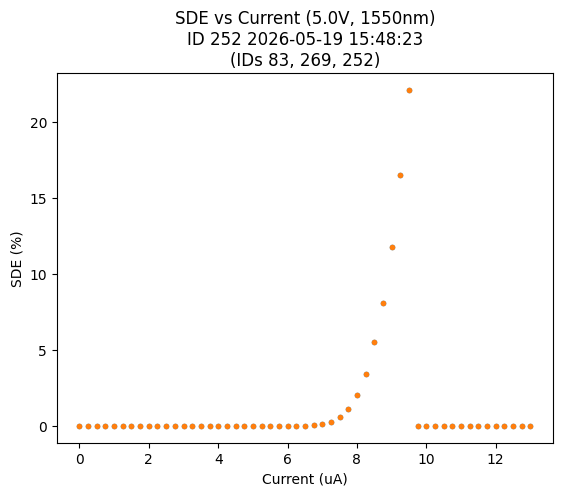

In [131]:
# Expected
IDnp = params.NphotonsID['vs_dB']
Nphotons = load_by_id(IDnp).get_parameter_data()['Nphotons']['Nphotons']
Nphotons_5v = Nphotons[-11]

# Light counts
IDlcr = params.device_line_2['IDs']['light_counts']['run_5v_2']
currents = load_by_id(IDlcr).get_parameter_data()['CR1']['yoko_current']
light_counts1 = load_by_id(IDlcr).get_parameter_data()['CR1']['CR1']
light_counts2 = load_by_id(IDlcr).get_parameter_data()['CR2']['CR2']
v_attenuator = load_by_id(IDlcr).get_parameter_data()['v_attenuator']['v_attenuator'][0]
wavelength = load_by_id(IDlcr).get_parameter_data()['wavelength']['wavelength'][0]

# Dark counts
IDdcr = params.device_line_2['IDs']['dark_counts']['run2']
dark_counts1 = load_by_id(IDdcr).get_parameter_data()['CR1']['CR1']
dark_counts2 = load_by_id(IDdcr).get_parameter_data()['CR2']['CR2']

# SDE
SDE1 = (light_counts1[~np.isnan(light_counts1)]-dark_counts1[~np.isnan(dark_counts1)])/Nphotons_5v
SDE2 = (light_counts2[~np.isnan(light_counts2)]-dark_counts2[~np.isnan(dark_counts2)])/Nphotons_5v
plt.plot(-currents[~np.isnan(currents)]*1e6, 100*SDE1, '.')
plt.plot(-currents[~np.isnan(currents)]*1e6, 100*SDE2, '.')
plt.ylabel('SDE (%)')
plt.xlabel('Current (uA)')
plt.title(params.make_title(ID=IDlcr, title=f'SDE vs Current ({v_attenuator}V, {wavelength*1e9:.0f}nm)', extra=f'(IDs {IDnp}, {IDdcr}, {IDlcr})'))


Text(0, 0.5, 'Light Counts (cps)')

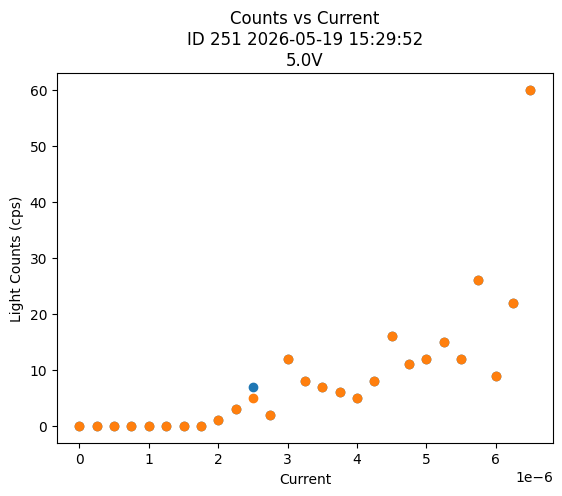

In [56]:
ID = 251
data = load_by_id(ID).get_parameter_data()
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
current = data['CR1']['yoko_current']
v_attenuator = data['v_attenuator']['v_attenuator']
plt.plot(-current, CR1, 'o', label='Threshold 1 (HIGH)')
plt.plot(-current, CR2, 'o', label='Threshold 2 (LOW)')
plt.title(params.make_title(ID=ID, title='Counts vs Current', extra = f'{v_attenuator[0]}V'))
plt.xlabel('Current')
plt.ylabel('Light Counts (cps)')

# Counts vs Attenuation 

In [8]:
Nphotons

array([1.90074794e+09, 1.63340728e+09, 1.39181398e+09, 1.17990623e+09,
       9.93194972e+08, 8.28519053e+08, 6.87763718e+08, 5.65331692e+08,
       4.62219739e+08, 3.74833825e+08, 3.00900145e+08, 2.40234497e+08,
       1.89891971e+08, 1.49239221e+08, 1.16361658e+08, 8.97035973e+07,
       6.87844852e+07, 5.21624943e+07, 3.94094219e+07, 2.95462790e+07,
       2.19141457e+07, 1.62007202e+07, 1.18550291e+07, 8.64929020e+06,
       6.27085844e+06, 4.51093825e+06, 3.22898466e+06, 2.29031767e+06,
       1.61830602e+06, 1.13287352e+06, 7.81332480e+05, 5.35985390e+05,
       3.60471558e+05, 2.39158407e+05, 1.55576822e+05, 9.86806616e+04,
       6.10062846e+04, 3.63869652e+04, 2.11538373e+04, 1.19165906e+04,
       6.63091126e+03, 3.94873099e+03, 2.79948501e+03])

In [7]:
v_attenuator

array([5.5 , 5.45, 5.4 , 5.35, 5.3 , 5.25, 5.2 , 5.15, 5.1 , 5.05, 5.  ,
       4.95, 4.9 , 4.85, 4.8 , 4.75, 4.7 , 4.65, 4.6 , 4.55, 4.5 , 4.45,
       4.4 , 4.35, 4.3 , 4.25, 4.2 , 4.15, 4.1 , 4.05, 4.  , 3.95, 3.9 ,
       3.85, 3.8 , 3.75, 3.7 , 3.65, 3.6 , 3.55, 3.5 , 3.45, 3.4 ])

In [10]:
light_counts1

array([  631.,  1092.,  1793.,  3042.,  5063.,  8744., 14357., 22607.,
       35461., 54286., 82355., 24797.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.])

Check match:-9.5e-06 (test) = [-9.5e-06]?


Text(0.5, 1.0, 'SDE vs Attenuation\nID 253 2026-05-19 16:40:33\nIbias=-9.5e-06\nmax 27.18%')

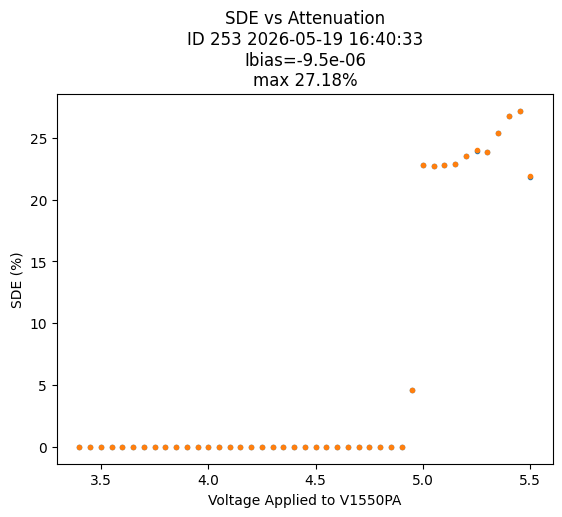

In [14]:
# Expected
IDnp = params.NphotonsID['vs_dB']
Nphotons = load_by_id(IDnp).get_parameter_data()['Nphotons']['Nphotons'][::-1] 

# Light counts 
IDlcr = params.device_line_2['IDs']['counts_vs_attenuation']['run1']
data = load_by_id(IDlcr).get_parameter_data()
current = data['yoko_current']['yoko_current']
v_attenuator = data['CR1']['v_attenuator']
light_counts1 = data['CR1']['CR1']
light_counts2 = data['CR2']['CR2']

# Dark counts
IDdcr = params.device_line_2['IDs']['dark_counts']['run2']
data_dcr = load_by_id(IDdcr).get_parameter_data()
current_dcr = data_dcr['CR1']['yoko_current']
idx, _ = params.match(-9.5e-6, current_dcr)
dark_counts1 = data_dcr['CR1']['CR1'][idx]
dark_counts2 = data_dcr['CR2']['CR2'][idx]


SDE1 = (light_counts1[~np.isnan(light_counts1)]-dark_counts1[~np.isnan(dark_counts1)])/Nphotons
SDE2 = (light_counts2[~np.isnan(light_counts2)]-dark_counts2[~np.isnan(dark_counts2)])/Nphotons
plt.plot(v_attenuator, 100*SDE1, '.')
plt.plot(v_attenuator, 100*SDE2, '.')
plt.ylabel('SDE (%)')
plt.xlabel(f'Voltage Applied to {params.att_blue_name}')
# plt.title(f'{params.device_line_1['name']} Ibias={current}\n{100*max(SDE1):.2f}%\n ID {IDlcr}')
plt.title(params.make_title(ID=IDlcr, title='SDE vs Attenuation', extra=f'Ibias={current[0]}\nmax {100*max(SDE1):.2f}%'))

Counts vs attenuation

Text(0.5, 1.0, 'Counts vs Attenuator Voltage\nID 253 2026-05-19 16:40:33\n1550nm, -9.5uA')

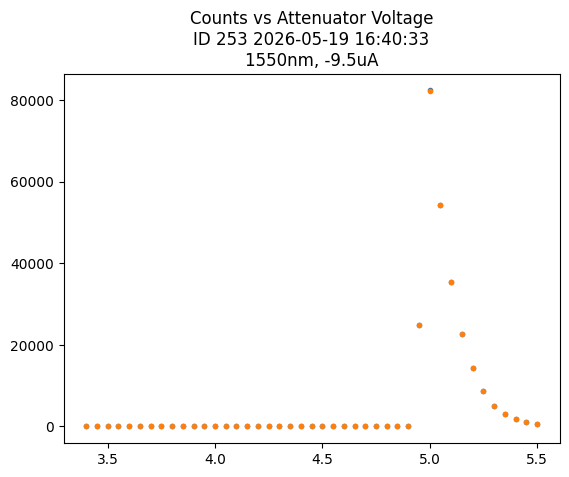

In [138]:
ID = params.device_line_2['IDs']['counts_vs_attenuation']['run1']
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
v_attenuator = data['CR1']['v_attenuator']
light_counts1 = data['CR1']['CR1']
light_counts2 = data['CR2']['CR2']
plt.plot(v_attenuator, light_counts1, '.')
plt.plot(v_attenuator, light_counts2, '.')
plt.title(params.make_title(ID=ID, title='Counts vs Attenuator Voltage', extra = f'{wavelength*1e9:.0f}nm, {current[0]*1e6}uA'))

In [143]:
IDdcr = params.device_line_2['IDs']['dark_counts']['run2']
data = load_by_id(IDdcr).get_parameter_data()
current_dcr = data['CR1']['yoko_current']
idx, _ = params.match(-9.5e-6, current_dcr)
dark_counts1 = data['CR1']['CR1'][idx]

Check match:-9.5e-06 (test) = [-9.5e-06]?


In [144]:
dark_counts1

array([18.66666667])

Check match:-9.5e-06 (test) = [-9.5e-06]?


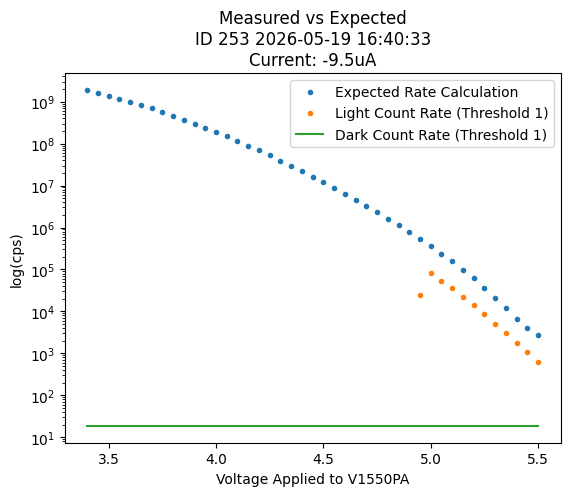

In [146]:
IDnp = params.NphotonsID['vs_dB']
Nphotons = load_by_id(IDnp).get_parameter_data()['Nphotons']['Nphotons']

ID = params.device_line_2['IDs']['counts_vs_attenuation']['run1']
current = load_by_id(ID).get_parameter_data()['yoko_current']['yoko_current']
v_attenuator = np.arange(params.att_blue_v_attenuator_range['start'], 
                         params.att_blue_v_attenuator_range['stop'],  
                         params.att_blue_v_attenuator_range['step'])
light_counts1 = load_by_id(ID).get_parameter_data()['CR1']['CR1']

IDdcr = params.device_line_2['IDs']['dark_counts']['run2']
data_dcr = load_by_id(IDdcr).get_parameter_data()
current_dcr = data_dcr['CR1']['yoko_current']
idx, _ = params.match(-9.5e-6, current_dcr)
dark_counts1 = data_dcr['CR1']['CR1'][idx]

plt.semilogy(v_attenuator[::-1], Nphotons[::-1], '.', label='Expected Rate Calculation')
plt.semilogy(v_attenuator[::-1], light_counts1[~np.isnan(light_counts1)], '.', label='Light Count Rate (Threshold 1)')

dcr1line = np.ones_like(Nphotons[::-1])*dark_counts1
plt.semilogy(v_attenuator[::-1], dcr1line, '-', label='Dark Count Rate (Threshold 1)')

plt.ylabel('log(cps)')
plt.xlabel(f'Voltage Applied to {params.att_blue_name}')
plt.title(params.make_title(ID=ID, title='Measured vs Expected', extra=f'Current: {current[0]*1e6}uA'))
plt.legend()

# Counts vs Wavelength

Check match:-9.5e-06 (test) = [-9.5e-06]?


Text(0.5, 1.0, 'SDE vs Wavelength\nID 254 2026-05-19 16:54:46\n5.0V, -9.5e-06uA')

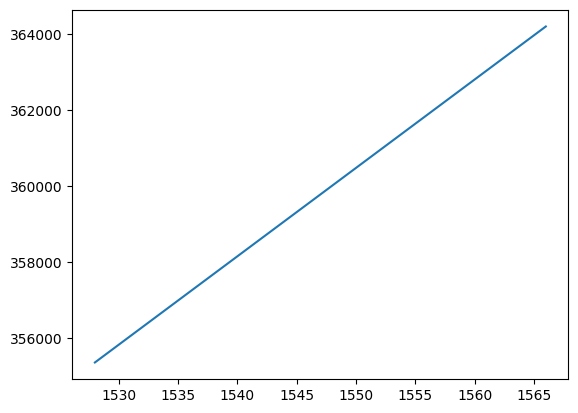

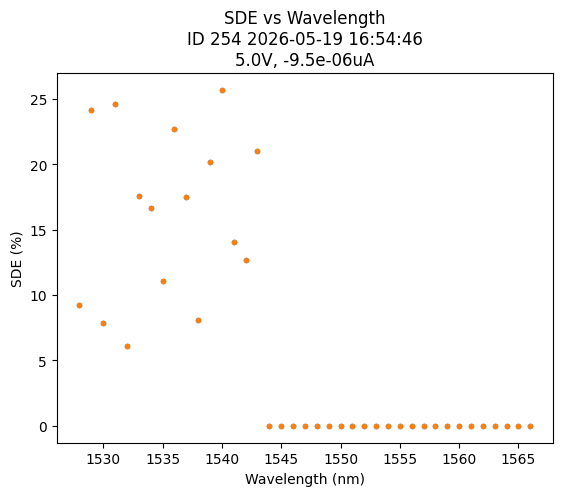

In [27]:
# Expected

IDnp = 142
data = load_by_id(IDnp).get_parameter_data()
attenuation = data['attenuation']['attenuation']
Nphotons = data['Nphotons']['Nphotons']
wavelength = data['wavelength']['wavelength']
plt.plot(wavelength*1e9, Nphotons)
plt.figure()

# Light counts
IDwav = params.device_line_2['IDs']['wavelength']['run5v']
wavelengths = load_by_id(IDwav).get_parameter_data()['wavelength']['wavelength']
light_counts1 = load_by_id(IDwav).get_parameter_data()['CR1']['CR1']
light_counts2 = load_by_id(IDwav).get_parameter_data()['CR2']['CR2']
total_counts1 = load_by_id(IDwav).get_parameter_data()['total_counts1']['total_counts1']
v_attenuator = load_by_id(IDwav).get_parameter_data()['v_attenuator']['v_attenuator'][0]
current = load_by_id(IDwav).get_parameter_data()['yoko_current']['yoko_current'][0]

# Dark counts 
IDdcr = params.device_line_1['IDs']['dark_counts']
currents_dcr = load_by_id(IDdcr).get_parameter_data()['yoko_current']['yoko_current']
idx, _ = params.match(-9.5e-6, currents_dcr)
dark_counts1 = load_by_id(IDdcr).get_parameter_data()['CR1']['CR1'][idx]
dark_counts2 = load_by_id(IDdcr).get_parameter_data()['CR2']['CR2'][idx]

# SDE 
SDE1 = (light_counts1[~np.isnan(light_counts1)]-dark_counts1[~np.isnan(dark_counts1)])/Nphotons_5v
SDE2 = (light_counts2[~np.isnan(light_counts2)]-dark_counts2[~np.isnan(dark_counts2)])/Nphotons_5v
plt.plot(wavelengths[~np.isnan(wavelengths)]*1e9, 100*SDE1, '.')
plt.plot(wavelengths[~np.isnan(wavelengths)]*1e9, 100*SDE2, '.')
plt.ylabel('SDE (%)')
plt.xlabel('Wavelength (nm)')
title = params.make_title(ID=IDwav, title='SDE vs Wavelength', extra=f'{v_attenuator}V, {current}uA')
plt.title(title)


In [29]:
IDwav = params.device_line_2['IDs']['wavelength']['run5v']
wavelengths = load_by_id(IDwav).get_parameter_data()['wavelength']['wavelength']
light_counts1 = load_by_id(IDwav).get_parameter_data()['CR1']['CR1']
light_counts2 = load_by_id(IDwav).get_parameter_data()['CR2']['CR2']
total_counts1 = load_by_id(IDwav).get_parameter_data()['total_counts1']['total_counts1']
v_attenuator = load_by_id(IDwav).get_parameter_data()['v_attenuator']['v_attenuator'][0]
current = load_by_id(IDwav).get_parameter_data()['yoko_current']['yoko_current'][0]

In [37]:
threshold2 = load_by_id(IDwav).get_parameter_data()['threshold2']['threshold2']

In [38]:
threshold2

array([0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06,
       0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06,
       0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06,
       0.06, 0.06, 0.06, 0.06, 0.06, 0.06,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  n

In [35]:
threshold1 = load_by_id(IDwav).get_parameter_data()['threshold1']['threshold1']

In [36]:
threshold1

array([0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06,
       0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06,
       0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06, 0.06,
       0.06, 0.06, 0.06, 0.06, 0.06, 0.06,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  n

In [34]:
light_counts1

array([33397., 87223., 28388., 88757., 21959., 63338., 60077., 40054.,
       81942., 63011., 29310., 72906., 92646., 50734., 45738., 75856.,
           0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.,     0.,     0.,     0.,     0.,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
      

In [33]:
load_by_id(IDwav).get_parameter_data()['pmeter90']['pmeter90']

array([0.00493313, 0.00492436, 0.00487911, 0.00486308, 0.00481889,
       0.00479659, 0.00479202, 0.00474989, 0.00475268, 0.00475025,
       0.0047593 , 0.0047245 , 0.00474295, 0.00478649, 0.00476215,
       0.00475557, 0.0047866 , 0.0048145 , 0.00480162, 0.00482428,
       0.00486471, 0.00486752, 0.00488706, 0.00489181, 0.00494573,
       0.00499546, 0.00497512, 0.00505627, 0.00505864, 0.0050924 ,
       0.00510734, 0.00513901, 0.00520314, 0.00521133, 0.00525197,
       0.00530621, 0.00531336, 0.00533515, 0.00536919,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        

In [30]:
power90 = load_by_id(IDwav).get_parameter_data()['power90']['power90']

KeyError: 'power90'

# Traces

In [22]:
IDs_traces = params.device_line_2['IDs']['traces']

{'start': 257, 'stop': 268}

In [2]:
IDs_traces = params.device_line_2['IDs']['traces']
min_id = IDs_traces['start']
max_id = IDs_traces['stop']

def plot_traces(ID):
    plot_by_id(ID)
    data = load_by_id(ID).get_parameter_data()
    # trace = data['trace']['trace']
    # time_axis = data['time']['time']
    # plt.plot(time_axis, trace)
    current = data['yoko_current']['yoko_current']
    print(current)

interact(plot_traces, ID=IntSlider(min=min_id, max=max_id, step=1, value=min_id,
                                  continuous_update=False));



interactive(children=(IntSlider(value=257, continuous_update=False, description='ID', max=268, min=257), Outpu…